In [3]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
import matplotlib as mpl
from helpers.simulation import *
from helpers.qtransform import *
from helpers.config import *

from scipy.stats import truncnorm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from skimage.feature import peak_local_max

from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

import warnings
warnings.filterwarnings("ignore")

In [34]:
mixed_dict = {}
with h5py.File(mixed_testset_path, 'r+') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][250:]

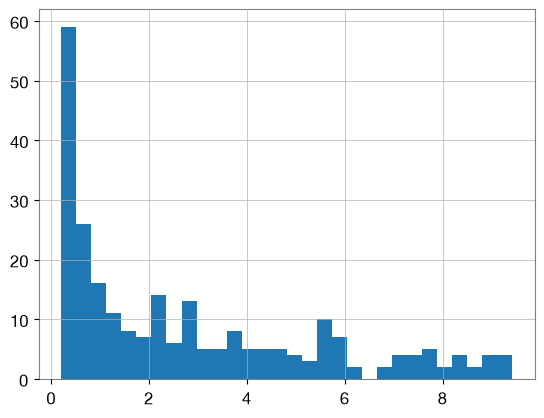

In [44]:
Mc = chirp_mass(mixed_dict['m1'], mixed_dict['m2'])
d_arr = mixed_dict['d']
z_arr = z_at_value(Planck18.luminosity_distance, d_arr*u.Mpc)
#plt.hist(np.log10(d_arr), bins=30)
plt.hist(z_arr, bins=30)
plt.show()

In [38]:
threshold = 5
Qvals = np.array([6, 16])
gw_found, glitch_found, both_found, none_found = [],[],[],[]
for i in range(mixed_dict['QT'].shape[0]):
    idx = np.argmin(np.abs(mixed_dict['tcen'][i]))
    image = mixed_dict['QT'][i, idx, :, :, :]
    t_axis = mixed_dict['t_qscan'][i, idx, :, 0]
    f_axis = mixed_dict['f_qscan'][i, idx, :, 0]
    sep = mixed_dict['sep'][i]

    F_grid, T_grid, _ = np.meshgrid(f_axis, t_axis, Qvals, indexing="ij")

    snr = np.sqrt(image**2 - 1)
    mask = (snr > threshold)

    F_opt = F_grid[mask]
    T_opt = T_grid[mask]/3600

    try:
        times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
        pdf = gaussian_kde(T_opt)(times)

        peaks, props = find_peaks(pdf, width=1, prominence=0.05)
        found = times[peaks]

        if len(found[found < 5]) > 0 and len(found[found > 5]) > 0:
            both_found.append(i)
        elif len(found) == 0:
            none_found.append(i)
        elif sep >= 0:
            if len(found[found < 5]) > 0:
                glitch_found.append(i)
            elif len(found[found > 5]) > 0:
                gw_found.append(i)
        elif sep < 0:
            if len(found[found > 5]) > 0:
                glitch_found.append(i)
            elif len(found[found < 5]) > 0:
                gw_found.append(i)

    except:
        none_found.append(i)

gw_found = np.array(gw_found)
glitch_found = np.array(glitch_found)
both_found = np.array(both_found)
none_found = np.array(none_found)

In [39]:
len(gw_found), len(glitch_found), len(both_found), len(none_found)

(39, 56, 154, 1)

In [40]:
idx = glitch_found

m1_arr = mixed_dict['m1'][idx]
m2_arr = mixed_dict['m2'][idx]
d_arr = mixed_dict['d'][idx]
z_arr = z_at_value(Planck18.luminosity_distance, d_arr*u.Mpc)

Mc = chirp_mass(m1_arr, m2_arr)

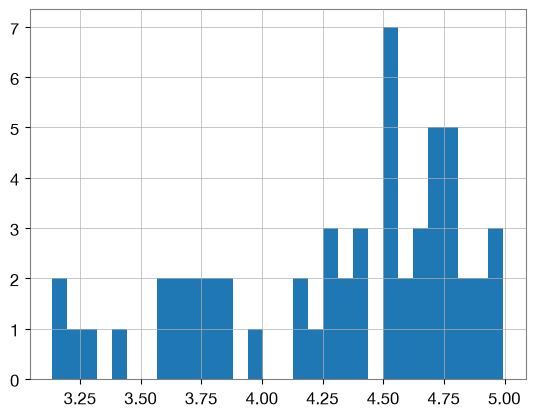

In [43]:
plt.hist(np.log10(d_arr), bins=30)
plt.show()

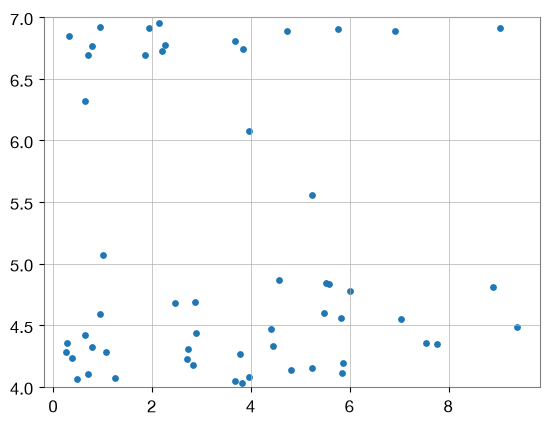

In [41]:
plt.scatter(z_arr, np.log10(Mc), s=15)
plt.ylim(4, 7)
#plt.xscale('log')
#plt.yscale('log')
plt.show()

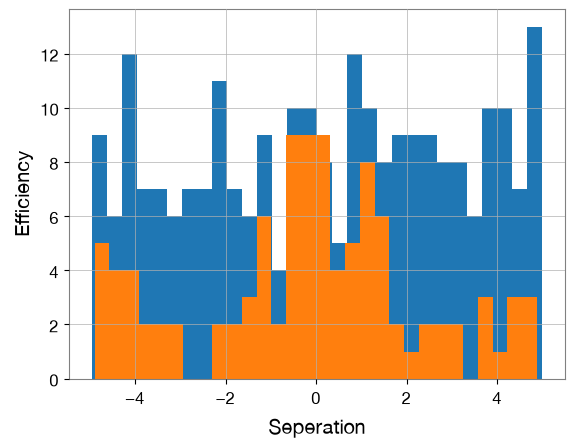

In [32]:
indices = both_found
indices = np.concatenate([gw_found, glitch_found, none_found]).astype(int)

sep_arr = mixed_dict['sep'][indices]
bins = np.arange(-3, 3, 0.25)
counts1, bin_edges1 = np.histogram(2*mixed_dict['sep'], bins=bins)
counts2, bin_edges2 = np.histogram(2*sep_arr, bins=bins)

bins = 0.5 * (bin_edges1[:-1] + bin_edges1[1:])
plt.hist(2*mixed_dict['sep'], bins=30)
plt.hist(2*sep_arr, bins=30)
plt.xlabel('Seperation')
plt.ylabel('Efficiency')
plt.show()

In [18]:
gw_dict = {}
#keys = ['QT', 't_qscan', 'f_qscan', 'tcen', 'sep']
with h5py.File(gw_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        gw_dict[key] = h5[key][:]

In [15]:
gw_dict['QT'].shape

(1000, 5, 256, 256, 2)

In [19]:
threshold = 8
Qvals = np.array([6, 16])
gw_found, none_found = [],[]
for i in range(gw_dict['QT'].shape[0]):
    idx = np.argmin(np.abs(gw_dict['tcen'][i]))
    image = gw_dict['QT'][i, idx, :, :, :]
    t_axis = gw_dict['t_qscan'][i, idx, :, 0]
    f_axis = gw_dict['f_qscan'][i, idx, :, 0]

    F_grid, T_grid, _ = np.meshgrid(f_axis, t_axis, Qvals, indexing="ij")

    snr = np.sqrt(image**2 - 1)
    mask = (snr > threshold)

    F_opt = F_grid[mask]
    T_opt = T_grid[mask]/3600

    try:
        times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
        pdf = gaussian_kde(T_opt)(times)

        peaks, props = find_peaks(pdf, width=1, prominence=0.05)
        found = times[peaks]

        if len(found) > 0:
            gw_found.append(i)
        elif len(found) == 0:
            none_found.append(i)

    except:
        none_found.append(i)

gw_found = np.array(gw_found)
none_found = np.array(none_found)

In [20]:
len(gw_found), len(none_found)

(997, 3)

## Training dataset filtering

In [2]:
with h5py.File(mixed_dataset_path, 'r+') as h5:
    t_qscan = h5['t_qscan'][:]
    f_qscan = h5['f_qscan'][:]

In [3]:
transient_dict = {}
with h5py.File(training_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        transient_dict[key] = h5[key][:]

In [7]:
idx = np.where(np.all(transient_dict['labels'] == [0, 0], axis=1))[0]
len(idx)

4999

In [4]:
idx = np.where(np.all(transient_dict['labels'] == [1, 1], axis=1))[0]
images = transient_dict['images'][idx]
labels = transient_dict['labels'][idx]
sim_idx = transient_dict['sim_index'][idx]
time_idx = transient_dict['time_index'][idx]

In [32]:
label = [1, 1]
sum(label)

2

In [5]:
threshold = 8
snrs = np.sqrt(images**2 - 1)
t_axes = t_qscan[sim_idx, time_idx, :, :]
f_axes = f_qscan[sim_idx, time_idx, :, :]

In [31]:
idx[good_idx]

array([10000, 10001, 10002, ..., 14992, 14993, 14994],
      shape=(3830,))

In [22]:
qvals = np.array([6, 16])
good_idx, bad_idx = [], []
for index in range(images.shape[0]):
    snr = snrs[index, :, :, :]
    t_axis = t_axes[index, :, 0]
    f_axis = f_axes[index, :, 0]
    
    F_grid, T_grid, Q_grid = np.meshgrid(f_axis, t_axis, qvals, indexing="ij")

    mask = (snr > threshold)
    T_opt = T_grid[mask]/3600
    try:
        times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
        pdf = gaussian_kde(T_opt)(times)
        peaks, props = find_peaks(pdf, width=1, prominence=0.05)

        if len(peaks) < 2:
            bad_idx.append(index)
        elif len(peaks) == 2:
            good_idx.append(index)
    except:
        pass

good_idx = np.array(good_idx)
bad_idx = np.array(bad_idx)

In [29]:
good_idx[:40]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,
       14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])

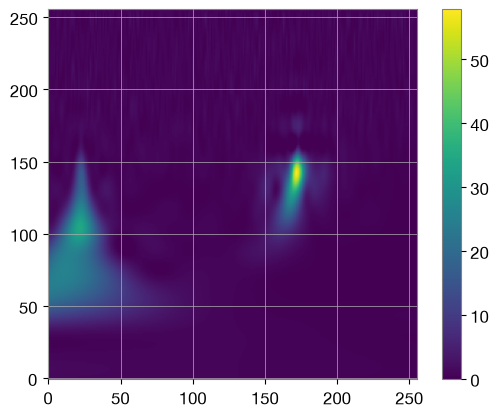

In [28]:
image = images[40]
plt.imshow(image[:, :, 0], origin='lower')
plt.colorbar()
plt.show()

In [157]:
def filter_by_snr(dataset_path, training_dict, label, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]

    idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]
    images = training_dict['images'][idx]
    sim_idx = training_dict['sim_index'][idx]
    time_idx = training_dict['time_index'][idx]

    snrs = np.sqrt(images**2 - 1)
    t_axes = t_qscan[sim_idx, time_idx, :, :]
    f_axes = f_qscan[sim_idx, time_idx, :, :]

    good_idx = []
    for index in range(images.shape[0]):
        T_opt = []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            t_axis = t_axes[index, :, j]
            f_axis = f_axes[index, :, j]
            _, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

            T_opt.append(T_grid[snr > threshold])
        
        T_opt = np.concatenate(T_opt)/3600
        if len(T_opt) < 2:
            if sum(label) == 0:
                good_idx.append(index)
            continue
        try:
            times = np.linspace(np.min(t_axes[index])/3600, np.max(t_axes[index])/3600, 1000)
            pdf = gaussian_kde(T_opt)(times)
            peaks, _ = find_peaks(pdf, width=1, prominence=0.05)

            if len(peaks) == sum(label):
                good_idx.append(index)
        except Exception as e:
            print(f"Sample {index}: {e}")

    good_idx = np.array(good_idx)
    return idx[good_idx]

In [ ]:
good_glitch = filter_by_snr(glitch_dataset_path, label=[0,1])

In [49]:
with h5py.File(training_dataset_path, 'r') as h5:
    sim_idx = h5['sim_index'][good_glitch]
    time_idx = h5['time_index'][good_glitch]

In [52]:
with h5py.File(glitch_dataset_path, 'r') as h5:
    inj_points = h5['inj_point'][:]

In [61]:
inj_point = inj_points[np.unique(sim_idx)].astype(str)
inj_point = inj_points[:].astype(str)

for point in ['tm_12', 'tm_23', 'tm_13',
              'tm_21', 'tm_32', 'tm_31']:
    count = len(np.where(inj_point == point)[0])
    print(f'{count} samples in {point}.')

157 samples in tm_12.
162 samples in tm_23.
177 samples in tm_13.
164 samples in tm_21.
187 samples in tm_32.
153 samples in tm_31.


In [41]:
transient_dict = {}
with h5py.File(training_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        transient_dict[key] = h5[key][:]

In [43]:
for key in transient_dict.keys():
    print(transient_dict[key].shape)

(17502, 256, 256, 2)
(17502, 2)
(17502,)
(17502,)


## 2D Search

In [12]:
mixed_dict = {}
with h5py.File(gw_dataset_path, 'r+') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:250]

In [37]:
i = 7
idx = np.argmin(np.abs(mixed_dict['tcen'][i]))
image = mixed_dict['QT'][i, idx, :, :, 1]
t_axis = mixed_dict['t_qscan'][i, idx, :, 1]
f_axis = np.log10(mixed_dict['f_qscan'][i, idx, :, 1])

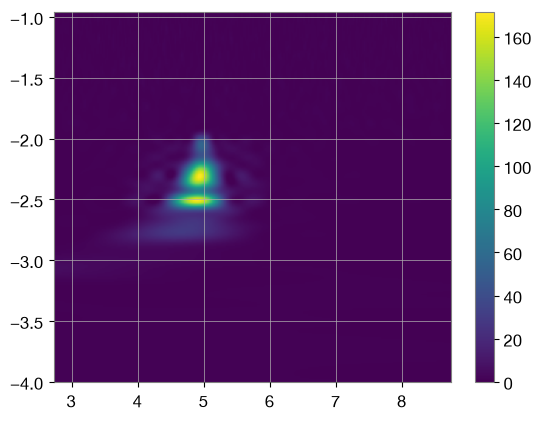

In [38]:
plt.imshow(image, extent=[t_axis[0]/3600, t_axis[-1]/3600, f_axis[0], f_axis[-1]],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
#plt.imshow(image, origin='lower')
plt.colorbar()

#plt.clim(0, 5)
#plt.ylabel('Log frequency')
#plt.xlabel('Time (hrs)')
plt.show()

In [39]:
threshold = 8
snr = np.sqrt(image**2 - 1)
F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

T_opt = T_grid[snr >= threshold]/3600
F_opt = F_grid[snr >= threshold]

times = np.linspace(np.min(T_opt), np.max(T_opt), 50)
log_freqs = np.linspace(np.min(F_opt), np.max(F_opt), 50)

In [40]:
samples = np.vstack((T_opt, F_opt))   # shape = (2, N)
kde = gaussian_kde(samples)
TT, FF = np.meshgrid(times, log_freqs, indexing="xy")
points = np.vstack((TT.ravel(), FF.ravel()))
pdf = kde(points).reshape(TT.shape)


In [45]:
from skimage.feature import peak_local_max

coords = peak_local_max(pdf, min_distance=10,      
    threshold_rel=0.5,exclude_border=False)

In [46]:
times[coords[:, 1]], log_freqs[coords[:, 0]]

(array([4.836735], dtype=float32), array([-2.549049], dtype=float32))

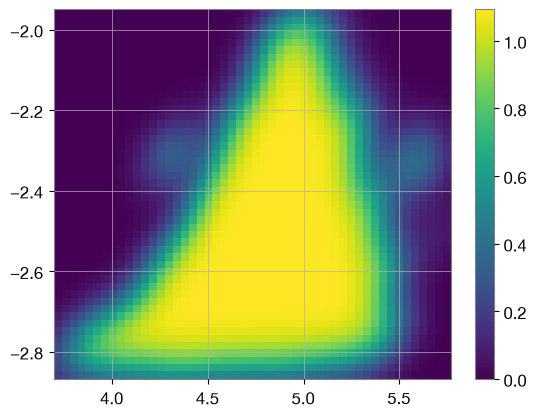

In [26]:
plt.imshow(pdf,extent=[times[0], times[-1], log_freqs[0], log_freqs[-1]], aspect='auto', origin='lower')
plt.colorbar()
#plt.scatter(coords[:, 1], coords[:, 0], s=15, marker='x', color='red')
plt.show()

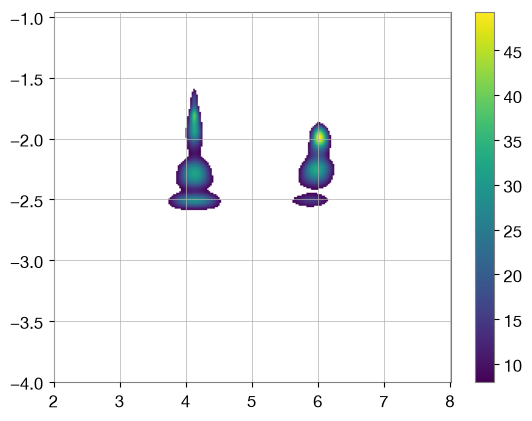

In [59]:
snr2 = snr.copy()
snr2[snr2 < 8] = np.nan
plt.imshow(snr2, extent=[t_axis[0]/3600, t_axis[-1]/3600, f_axis[0], f_axis[-1]],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
#plt.imshow(image, origin='lower')
plt.colorbar()

#plt.clim(0, 5)
#plt.ylabel('Log frequency')
#plt.xlabel('Time (hrs)')
plt.show()

In [33]:
training_dict = {}
with h5py.File(training_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        training_dict[key] = h5[key][:]

In [244]:
def filter_by_snr2(dataset_path, training_dict, label, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]

    idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]
    images = training_dict['images'][idx]
    sim_idx = training_dict['sim_index'][idx]
    time_idx = training_dict['time_index'][idx]

    snrs = np.sqrt(images**2 - 1)
    t_axes = t_qscan[sim_idx, time_idx, :, :]
    f_axes = f_qscan[sim_idx, time_idx, :, :]

    good_idx, counts = [], []
    for index in range(images.shape[0]):
        F_opt, T_opt = [], []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            t_axis = t_axes[index, :, j]/3600
            f_axis = np.log10(f_axes[index, :, j])
            F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

            T_opt.append(T_grid[snr >= threshold])
            F_opt.append(F_grid[snr >= threshold])
        
        T_opt = np.concatenate(T_opt)
        F_opt = np.concatenate(F_opt)
        if len(T_opt) < 2:
            if sum(label) == 0:
                good_idx.append(index)
            continue
        try:
            samples = np.vstack((T_opt, F_opt))
            kde = gaussian_kde(samples)

            times = np.linspace(np.min(T_opt), np.max(T_opt), 50)
            log_freqs = np.linspace(np.min(F_opt), np.max(F_opt), 50)

            TT, FF = np.meshgrid(times, log_freqs, indexing="xy")
            points = np.vstack((TT.ravel(), FF.ravel()))
            pdf = kde(points).reshape(TT.shape)

            coords = peak_local_max(pdf, min_distance=1,      
                    threshold_rel=0.2, exclude_border=False)
            counts.append(len(coords))
            if len(coords) >= sum(label):
                good_idx.append(index)
        except Exception as e:
            print(f"Sample {index}: {e}")
            counts.append(0)
        #if index%10 == 0:
         #   print(f'Image {index} out of {images.shape[0]} done')

    good_idx = np.array(good_idx)
    return idx[good_idx], np.array(counts)

In [307]:
def filter_by_snr2(dataset_path, training_dict, label, threshold=8):
    with h5py.File(dataset_path, 'r') as h5:
        t_qscan = h5['t_qscan'][:]
        f_qscan = h5['f_qscan'][:]

    idx = np.where(np.all(training_dict['labels'] == label, axis=1))[0]
    images = training_dict['images'][idx]
    sim_idx = training_dict['sim_index'][idx]
    time_idx = training_dict['time_index'][idx]

    snrs = np.sqrt(images**2 - 1)
    t_axes = t_qscan[sim_idx, time_idx, :, :]
    f_axes = f_qscan[sim_idx, time_idx, :, :]

    good_idx, counts = [], []
    for index in range(images.shape[0]):
        counts = []
        for j in range(snrs.shape[-1]):
            snr = snrs[index, :, :, j]
            image = images[index, :, :, j]
            image[snr <= threshold] = 0

            coords = peak_local_max(image, min_distance=10,      
                threshold_rel=0.04,exclude_border=False)
            
            counts.append(len(coords))
        
        if max(counts) >= sum(label):
            good_idx.append(index)
        #if index%10 == 0:
         #   print(f'Image {index} out of {images.shape[0]} done')

    good_idx = np.array(good_idx)
    return idx[good_idx]

In [308]:
good = filter_by_snr2(mixed_dataset_path, training_dict, label=[1,1], threshold=5)

In [158]:
good2 = filter_by_snr(mixed_dataset_path, training_dict, label=[1,1])

In [309]:
np.setdiff1d(good2, good)

array([], dtype=int64)

In [310]:
np.setdiff1d(good, good2)

array([], dtype=int64)

In [247]:
len(good2), len(good)

(4229, 4181)

In [297]:
idx = [9759]
images = training_dict['images'][idx]
sim_idx = training_dict['sim_index'][idx]
time_idx = training_dict['time_index'][idx]

snrs = np.sqrt(images**2 - 1)
t_axes = t_qscan[sim_idx, time_idx, :, :]
f_axes = f_qscan[sim_idx, time_idx, :, :]

threshold = 8
good_idx, counts = [], []
for index in range(images.shape[0]):
    if index == 10:
        break
    F_opt, T_opt = [], []
    for j in range(snrs.shape[-1]):
        snr = snrs[index, :, :, j]
        t_axis = t_axes[index, :, j]/3600
        f_axis = np.log10(f_axes[index, :, j])
        F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

        T_opt.append(T_grid[snr >= threshold])
        F_opt.append(F_grid[snr >= threshold])
    
    T_opt = np.concatenate(T_opt)
    F_opt = np.concatenate(F_opt)
    if len(T_opt) < 2:
        if sum(label) == 0:
            good_idx.append(index)
        continue
    try:
        samples = np.vstack((T_opt, F_opt))
        kde = gaussian_kde(samples)

        times = np.linspace(np.min(T_opt), np.max(T_opt), 50)
        log_freqs = np.linspace(np.min(F_opt), np.max(F_opt), 50)

        TT, FF = np.meshgrid(times, log_freqs, indexing="xy")
        points = np.vstack((TT.ravel(), FF.ravel()))
        pdf = kde(points).reshape(TT.shape)

        coords = peak_local_max(pdf, min_distance=2,      
                threshold_rel=0.2,exclude_border=False)
        #counts.append(len(coords))
        if len(coords) >= 2:
            good_idx.append(index)
            counts.append(len(coords))
    except Exception as e:
        print(f"Sample {index}: {e}")
        counts.append(0)
    #if index%10 == 0:
        #   print(f'Image {index} out of {images.shape[0]} done')


In [266]:
coords

array([[12, 36],
       [28,  4],
       [24, 35],
       [37, 35]])

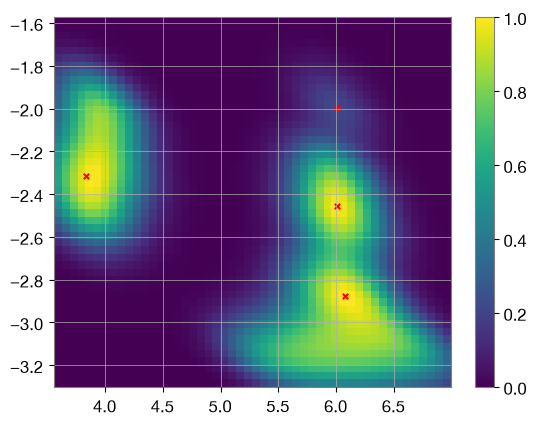

In [267]:
plt.imshow(pdf,extent=[times[0], times[-1], log_freqs[0], log_freqs[-1]], aspect='auto', origin='lower')

plt.scatter(times[coords[:,1]], log_freqs[coords[:,0]], s=15, color='red', marker='x')
plt.colorbar()

array([[171,  52]])

[[140  64]
 [101 196]
 [ 60 207]]


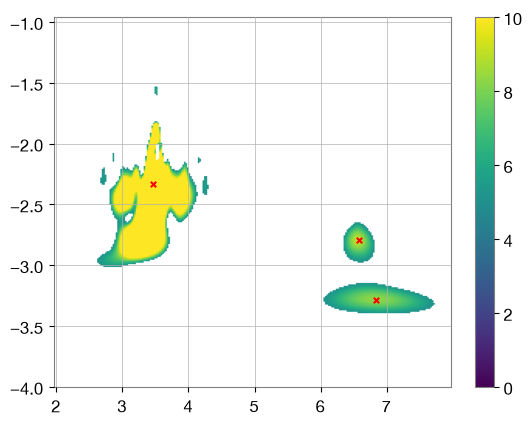

In [305]:
image = images[0,:,:,0]
snr = np.sqrt(image**2 - 1)
snr[snr < 5] = np.nan

image2 = image.copy()
image2[snr < 5] == 0
coords = peak_local_max(image2, min_distance=10,      
                threshold_rel=0.04,exclude_border=False)
print(coords)

plt.imshow(snr, extent=[t_axis[0], t_axis[-1], f_axis[0], f_axis[-1]],\
     aspect='auto', origin='lower')
plt.clim(0, 10)
plt.colorbar()
plt.scatter(t_axis[coords[:,1]], f_axis[coords[:,0]], s=15, color='red', marker='x')